In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# ロックイン検出: 弱い AM/FM 構造の復元

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_lockin_detection.ipynb)


ロックイン検出は、**速い搬送波の上に乗ったゆっくりした変調** を取り出したいときに使います。見たいのはキャリアそのものではなく、baseband へ落とした後に残る振幅・位相のトレンドです。

この公開版 notebook は legacy のヘテロダイン例を整理し、AM/FM 復元の本質に絞っています。

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

from gwexpy import TimeSeries

fs = 1024.0
duration = 40.0
t = np.arange(0, duration, 1 / fs)
np.random.seed(42)

# The carrier is the strong narrowband tone that transports the information we actually care about.
f_carrier = 100.0

# Slow AM and PM terms encode the physical drift to be recovered after demodulation.
amp_mod = 1.0 + 0.5 * np.sin(2 * np.pi * 0.2 * t)
phase_mod = 2.0 * np.sin(2 * np.pi * 0.05 * t)

clean_signal = amp_mod * np.cos(2 * np.pi * f_carrier * t + phase_mod)
noise = np.random.normal(0, 0.8, len(t))
ts = TimeSeries(clean_signal + noise, sample_rate=fs, name="Modulated Signal", unit="V")


## 1. `lock_in` で振幅と位相を取り出す

参照周波数を与えることで、キャリアと同相な成分だけを残し、広帯域雑音を平均で落とします。

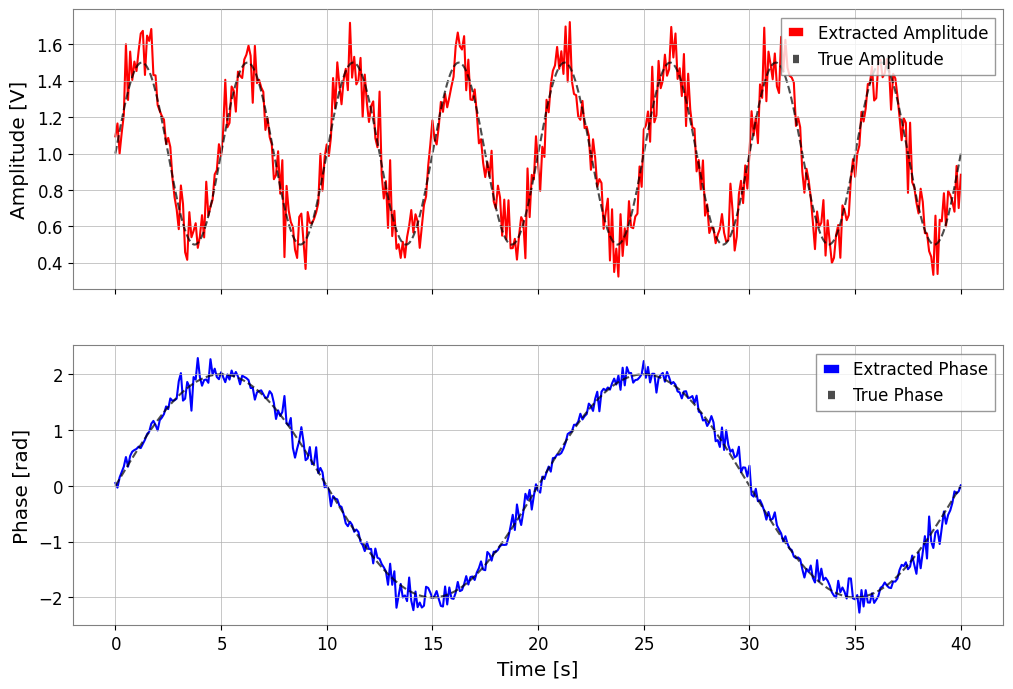

In [3]:
# stride sets the time resolution of the recovered baseband trend: shorter stride follows faster modulation but averages less noise.
amp, phase = ts.lock_in(f0=f_carrier, stride=0.1, output="amp_phase", deg=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(amp, label="Extracted Amplitude", color="red")
ax1.plot(t, amp_mod, label="True Amplitude", color="black", ls="--", alpha=0.7)
ax1.set_ylabel("Amplitude [V]")
ax1.legend()

ax2.plot(phase, label="Extracted Phase", color="blue")
ax2.plot(t, phase_mod, label="True Phase", color="black", ls="--", alpha=0.7)
ax2.set_ylabel("Phase [rad]")
ax2.legend()
plt.xlabel("Time [s]")
plt.show()


## 2. 手動復調でも同じ物理が見える

参照波との積を取ると DC 成分と `2*f_c` 成分ができます。低域フィルタは後者を落とし、ゆっくりした包絡と位相ドリフトだけを残します。

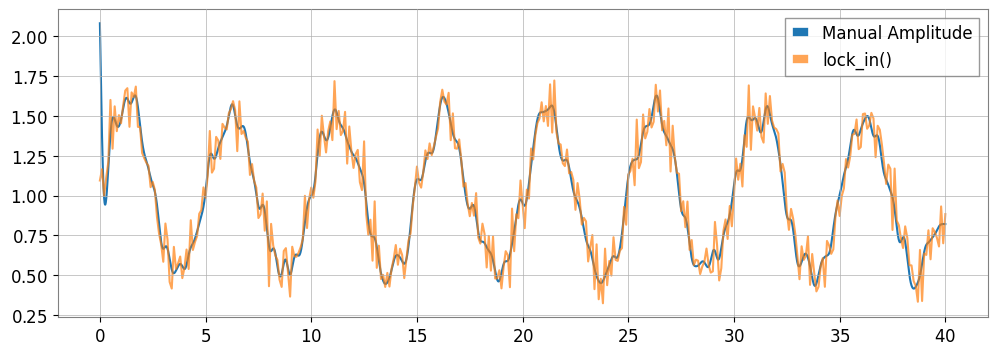

In [4]:
ref_cos = np.cos(2 * np.pi * f_carrier * t)
ref_sin = np.sin(2 * np.pi * f_carrier * t)

# Multiply by the reference to shift the carrier to baseband and create a mirrored image at 2*f_c.
mixed_i = (ts * ref_cos) * 2.0
mixed_q = (ts * (-ref_sin)) * 2.0

# Low-pass after mixing removes the 2*f_c image term so the slow modulation remains.
b, a = signal.butter(4, 2.0, fs=fs, btype="low")
i_filtered = TimeSeries(signal.filtfilt(b, a, mixed_i.value), sample_rate=fs)
q_filtered = TimeSeries(signal.filtfilt(b, a, mixed_q.value), sample_rate=fs)

amp_manual = np.sqrt(i_filtered**2 + q_filtered**2)
phase_manual = np.arctan2(q_filtered.value, i_filtered.value)

plt.figure(figsize=(12, 4))
plt.plot(amp_manual, label="Manual Amplitude")
plt.plot(amp, label="lock_in()", alpha=0.7)
plt.legend()
plt.show()


## 3. 復調すると情報は低周波へ移る

復調後のスペクトルは 0 Hz 近傍に集まるので、高周波キャリア問題が低周波トレンド解析の問題へ変わります。

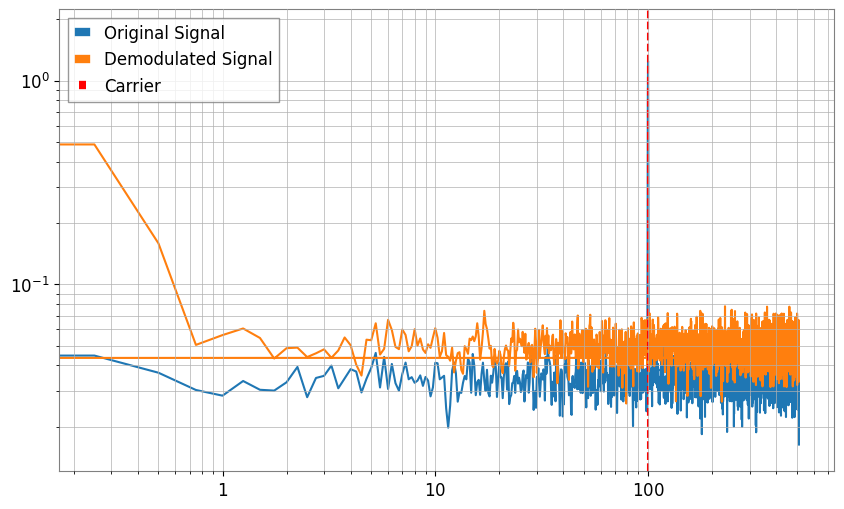

In [5]:
asd_raw = ts.asd(fftlength=4)
complex_signal = ts.lock_in(f0=f_carrier, stride=1 / fs, output="complex")
asd_demod = complex_signal.asd(fftlength=4)

plt.figure(figsize=(10, 6))
plt.loglog(asd_raw.frequencies, asd_raw.value, label="Original Signal")
plt.loglog(asd_demod.frequencies, asd_demod.value, label="Demodulated Signal")
plt.axvline(f_carrier, color="red", ls="--", label="Carrier")
plt.legend()
plt.grid(True, which="both")
plt.show()
